# Does the P2/P$\Omega$ asymmetry reflect chemistry, or just identity?

The paper's abstract states that P2 "requires a specific side chain" while P$\Omega$ "imposes only a
permissive backbone constraint" -- a claim about side-chain *identity*, deliberately stripped of any
appeal to "chemistry" because nothing in the recovery-rate analysis (`03_recovery_presentation.ipynb`)
actually measures amino-acid physicochemical properties. This notebook runs that missing test directly:
does P$\Omega$'s low exact-identity recovery ($0.19$) reflect a pocket that is genuinely indifferent to
what side chain sits there, or one that discriminates on a coarser physicochemical axis (hydrophobicity,
charge, size) while tolerating many different specific residues that share that property? Two independent
representations of "chemistry" are used throughout -- a discrete 5-class side-chain scheme (nonpolar
aliphatic / aromatic / polar uncharged / basic / acidic) and the continuous Kyte-Doolittle hydrophobicity
scale -- so a finding that holds on one but not the other is reported as such, not collapsed into a
single verdict.

1. Native anchor chemistry across the panel (model-independent baseline)
2. Identity-level vs. chemistry-class-level diversity of designed residues
3. Crystal-level statistical tests: is either anchor chemically restricted beyond a random interior position?
4. From exact-identity recovery to chemistry-class match: how much of the P$\Omega$ gap closes?
5. Continuous hydrophobicity distributions of designed residues
6. Does removing the TCR erode chemistry-level constraint, or just identity-level recovery?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import entropy as scipy_entropy, wilcoxon

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel7_chemistry"
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODELS = ["vanilla", "noMHC", "ESM-IF1", "LigandMPNN"]
MODEL_COLOR = {"vanilla": "#0072B2", "noMHC": "#E69F00", "ESM-IF1": "#009E73", "LigandMPNN": "#CC79A7"}
MODEL_LABEL = {"vanilla": "ProteinMPNN", "noMHC": "ProteinMPNN (no MHC)", "ESM-IF1": "ESM-IF1",
               "LigandMPNN": "LigandMPNN"}
POS_COLOR = {"P2": "#0072B2", "P-Omega": "#D55E00", "Interior": "#999999"}

KD = {"A": 1.8, "R": -4.5, "N": -3.5, "D": -3.5, "C": 2.5, "Q": -3.5, "E": -3.5, "G": -0.4, "H": -3.2,
      "I": 4.5, "L": 3.8, "K": -3.9, "M": 1.9, "F": 2.8, "P": -1.6, "S": -0.8, "T": -0.7, "W": -0.9,
      "Y": -1.3, "V": 4.2}
CHEM_CLASS = {}
for aa in "GAVLIPM": CHEM_CLASS[aa] = "nonpolar_aliphatic"
for aa in "FYW": CHEM_CLASS[aa] = "aromatic"
for aa in "STCNQ": CHEM_CLASS[aa] = "polar_uncharged"
for aa in "KRH": CHEM_CLASS[aa] = "basic"
for aa in "DE": CHEM_CLASS[aa] = "acidic"
CLASS_COLOR = {"nonpolar_aliphatic": "#0072B2", "aromatic": "#009E73", "polar_uncharged": "#E69F00",
              "basic": "#CC79A7", "acidic": "#D55E00"}
CLASSES = list(CLASS_COLOR.keys())

meta = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_metadata.csv")
meta_mhconly = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_metadata_mhconly.csv")
natives = meta.groupby("pdb")["native"].first().to_dict()
PDBS = sorted(natives.keys())
print(f"{len(PDBS)} structures, {len(MODELS)} models, full: {len(meta)} unique designs, "
     f"no-TCR: {len(meta_mhconly)} unique designs")

def interior_idx_of(length):
    excluded = {0, 1, length - 1}
    return [i for i in range(length) if i not in excluded]

def position_entropy(residues, alphabet_size):
    counts = pd.Series(residues).value_counts()
    p = counts.values / counts.values.sum()
    return scipy_entropy(p, base=2) / np.log2(alphabet_size)

def group_stats(peptides, native, idx_list):
    recs, cms, kdvars, entaas, entcls = [], [], [], [], []
    for idx in idx_list:
        residues = [p[idx] for p in peptides]
        nat = native[idx]
        recs.append(np.mean([r == nat for r in residues]))
        cms.append(np.mean([CHEM_CLASS[r] == CHEM_CLASS[nat] for r in residues]))
        kdvars.append(np.var([KD[r] for r in residues]))
        entaas.append(position_entropy(residues, 20))
        entcls.append(position_entropy([CHEM_CLASS[r] for r in residues], 5))
    return dict(recovery=np.mean(recs), class_match=np.mean(cms), kd_var=np.mean(kdvars),
               entropy_aa=np.mean(entaas), entropy_class=np.mean(entcls))

def build_stats_df(data):
    rows = []
    for pdb in PDBS:
        native = natives[pdb]
        length = len(native)
        interior_idx = interior_idx_of(length)
        for model in MODELS:
            peps = data.loc[(data.pdb == pdb) & (data.model == model), "peptide"].tolist()
            if not peps:
                continue
            row = {"pdb": pdb, "model": model, "n": len(peps)}
            for prefix, idx_list in [("p2", [1]), ("pomega", [length - 1]), ("interior", interior_idx)]:
                for k, v in group_stats(peps, native, idx_list).items():
                    row[f"{prefix}_{k}"] = v
            rows.append(row)
    return pd.DataFrame(rows)

stats_full = build_stats_df(meta)
stats_mhconly = build_stats_df(meta_mhconly)
print(f"stats_full: {stats_full.shape}, stats_mhconly: {stats_mhconly.shape}")

40 structures, 4 models, full: 7828 unique designs, no-TCR: 19000 unique designs


stats_full: (156, 18), stats_mhconly: (159, 18)


## 1. Native anchor chemistry across the panel

Independent of any design model: what is the actual side chain at P2 and P$\Omega$ in each of the 19
native peptides, and how hydrophobic is it (Kyte-Doolittle scale) relative to that same peptide's own
interior positions (P3 through the second-to-last position, excluding P1)? This is pure sequence fact,
establishing the chemistry a design model would need to reproduce before asking whether it does.

 pdb     native p2_res           p2_class pomega_res       pomega_class
1BD2  LLFGYPVYV      L nonpolar_aliphatic          V nonpolar_aliphatic
1LP9  ALWGFFPVL      L nonpolar_aliphatic          L nonpolar_aliphatic
1OGA  GILGFVFTL      I nonpolar_aliphatic          L nonpolar_aliphatic
1QRN  LLFGYAVYV      L nonpolar_aliphatic          V nonpolar_aliphatic
1QSE  LLFGYPRYV      L nonpolar_aliphatic          V nonpolar_aliphatic
1QSF  LLFGYPVAV      L nonpolar_aliphatic          V nonpolar_aliphatic
2BNQ  SLLMWITQV      L nonpolar_aliphatic          V nonpolar_aliphatic
2BNR  SLLMWITQC      L nonpolar_aliphatic          C    polar_uncharged
2F53  SLLMWITQC      L nonpolar_aliphatic          C    polar_uncharged
2F54  SLLMWITQC      L nonpolar_aliphatic          C    polar_uncharged
2GJ6  LLFGKPVYV      L nonpolar_aliphatic          V nonpolar_aliphatic
2J8U  ALWGFFPVL      L nonpolar_aliphatic          L nonpolar_aliphatic
2JCC  ALWGFFPVL      L nonpolar_aliphatic          L nonpolar_al

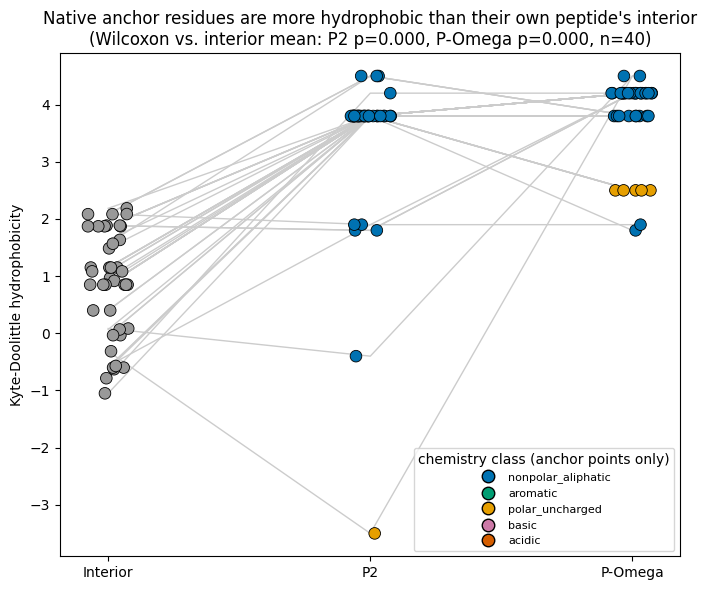

wrote /home/ubuntu/if-mhc/figures/fig_panel7_chemistry/fig_panel7_native_anchor_hydrophobicity.png


In [2]:
rows_nat = []
for pdb in PDBS:
    native = natives[pdb]
    length = len(native)
    interior_idx = interior_idx_of(length)
    interior_kd_mean = np.mean([KD[native[i]] for i in interior_idx])
    rows_nat.append({"pdb": pdb, "native": native, "p2_res": native[1], "p2_class": CHEM_CLASS[native[1]],
                     "p2_kd": KD[native[1]], "pomega_res": native[-1],
                     "pomega_class": CHEM_CLASS[native[-1]], "pomega_kd": KD[native[-1]],
                     "interior_kd_mean": interior_kd_mean})
nat_df = pd.DataFrame(rows_nat)
print(nat_df[["pdb", "native", "p2_res", "p2_class", "pomega_res", "pomega_class"]].to_string(index=False))
print()
print("native P2 chemistry class counts:     ", dict(nat_df["p2_class"].value_counts()))
print("native P-Omega chemistry class counts:", dict(nat_df["pomega_class"].value_counts()))

_, p_p2 = wilcoxon(nat_df["p2_kd"], nat_df["interior_kd_mean"])
_, p_pom = wilcoxon(nat_df["pomega_kd"], nat_df["interior_kd_mean"])
print(f"\nWilcoxon, native KD hydrophobicity vs. each peptide's own interior mean (n={len(nat_df)}):")
print(f"  P2:      {nat_df['p2_kd'].mean():.2f} vs {nat_df['interior_kd_mean'].mean():.2f}, p={p_p2:.4f}")
print(f"  P-Omega: {nat_df['pomega_kd'].mean():.2f} vs {nat_df['interior_kd_mean'].mean():.2f}, p={p_pom:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
rng = np.random.RandomState(0)
x_pos = {"Interior": 0, "P2": 1, "P-Omega": 2}
for _, row in nat_df.iterrows():
    ax.plot([x_pos["Interior"], x_pos["P2"], x_pos["P-Omega"]],
           [row["interior_kd_mean"], row["p2_kd"], row["pomega_kd"]], color="#CCCCCC", linewidth=1, zorder=1)
for label, x in x_pos.items():
    if label == "Interior":
        vals, colors = nat_df["interior_kd_mean"], ["#999999"] * len(nat_df)
    elif label == "P2":
        vals, colors = nat_df["p2_kd"], [CLASS_COLOR[c] for c in nat_df["p2_class"]]
    else:
        vals, colors = nat_df["pomega_kd"], [CLASS_COLOR[c] for c in nat_df["pomega_class"]]
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), x) + jitter, vals, s=70, color=colors, edgecolor="black",
              linewidth=0.6, zorder=3)
ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels(list(x_pos.keys()))
ax.set_ylabel("Kyte-Doolittle hydrophobicity")
ax.set_title("Native anchor residues are more hydrophobic than their own peptide's interior\n"
             f"(Wilcoxon vs. interior mean: P2 p={p_p2:.3f}, P-Omega p={p_pom:.3f}, n={len(nat_df)})")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=CLASS_COLOR[c],
                      markeredgecolor="black", markersize=9, label=c) for c in CLASSES]
ax.legend(handles=handles, title="chemistry class (anchor points only)", fontsize=8, loc="lower right")
fig.tight_layout()
out = FIG_DIR / "fig_panel7_native_anchor_hydrophobicity.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 2. Identity-level vs. chemistry-class-level diversity of designed residues

Per-position Shannon entropy over the full 20-letter amino-acid alphabet (normalized by $\log_2 20$)
versus entropy over the 5-class chemistry scheme (normalized by $\log_2 5$), computed the same way at
P2, P$\Omega$, and the interior reference group (mirrors the Methods section's diversity metric, applied
here to two different alphabets). If P$\Omega$'s high identity-level diversity collapses onto a low
chemistry-class-level diversity, that is direct evidence the pocket enforces a physicochemical constraint
even though it does not enforce a specific residue.

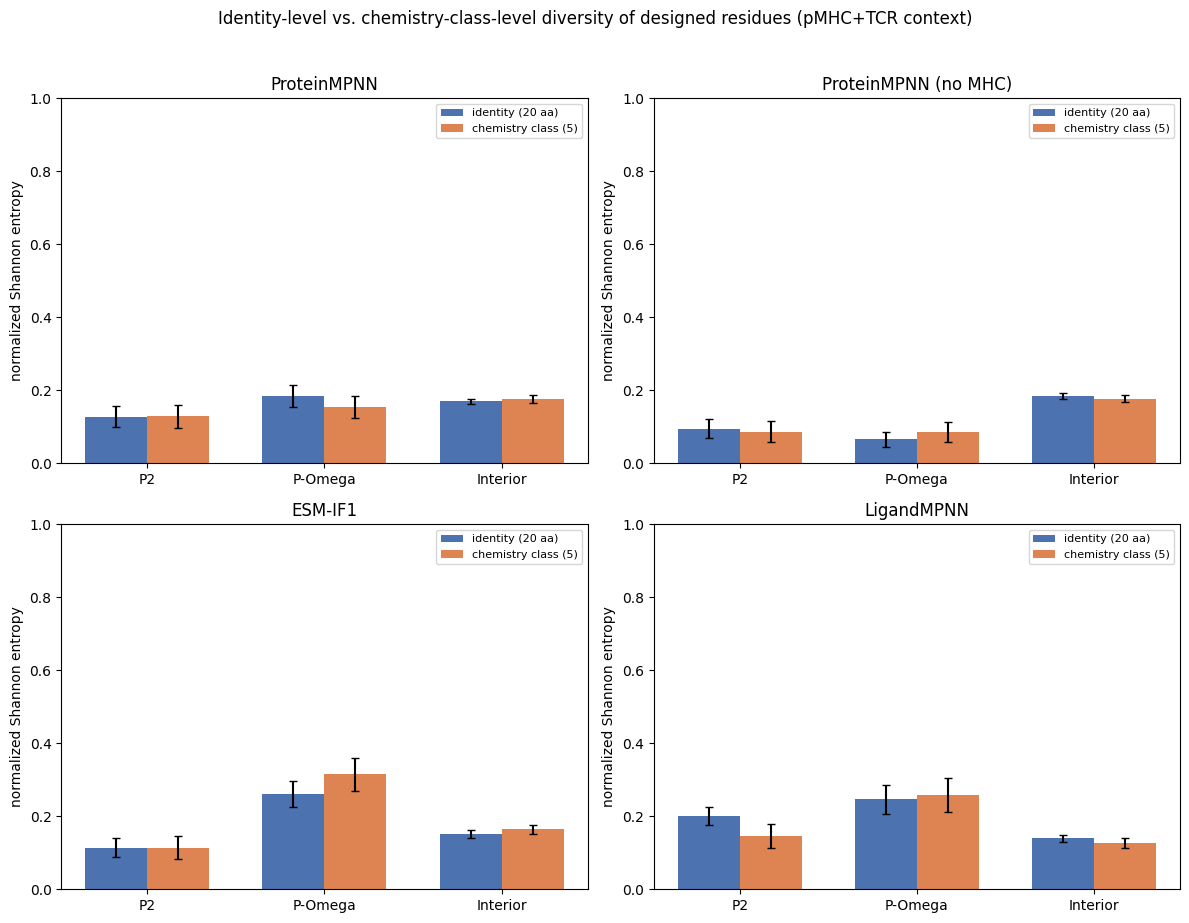

wrote /home/ubuntu/if-mhc/figures/fig_panel7_chemistry/fig_panel7_entropy_identity_vs_class.png


In [3]:
groups = ["P2", "P-Omega", "Interior"]
prefix_map = {"P2": "p2", "P-Omega": "pomega", "Interior": "interior"}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, model in zip(axes.flat, MODELS):
    sub = stats_full[stats_full.model == model]
    aa_means = [sub[f"{prefix_map[g]}_entropy_aa"].mean() for g in groups]
    aa_sems = [sub[f"{prefix_map[g]}_entropy_aa"].sem() for g in groups]
    cls_means = [sub[f"{prefix_map[g]}_entropy_class"].mean() for g in groups]
    cls_sems = [sub[f"{prefix_map[g]}_entropy_class"].sem() for g in groups]
    x = np.arange(len(groups))
    width = 0.35
    ax.bar(x - width / 2, aa_means, width, yerr=aa_sems, capsize=3, color="#4C72B0",
          label="identity (20 aa)")
    ax.bar(x + width / 2, cls_means, width, yerr=cls_sems, capsize=3, color="#DD8452",
          label="chemistry class (5)")
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1)
    ax.set_ylabel("normalized Shannon entropy")
    ax.set_title(MODEL_LABEL[model])
    ax.legend(fontsize=8)
fig.suptitle("Identity-level vs. chemistry-class-level diversity of designed residues (pMHC+TCR context)",
            y=1.02)
fig.tight_layout()
out = FIG_DIR / "fig_panel7_entropy_identity_vs_class.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 3. Crystal-level statistical tests: is either anchor chemically restricted beyond a random interior position?

Same design as the paper's anchor-recovery test (`03_recovery_presentation.ipynb`, Section 2a): average
across the 4 models first (one value per crystal x position group, $n=19$ independent crystals), then a
paired Wilcoxon test against the fixed interior reference group, Bonferroni-corrected by 2 within each
metric family. Three metrics per anchor: chemistry-class match rate, hydrophobicity variance (KD), and
exact-identity recovery (reproduced here for reference, not novel). Run in both structural contexts.

In [4]:
def crystal_level_tests(stats_df, label):
    value_cols = [c for c in stats_df.columns if c not in ("pdb", "model", "n")]
    cl = stats_df.groupby("pdb")[value_cols].mean()
    print(f"=== {label} (n={len(cl)} crystals, averaged across {len(MODELS)} models) ===")
    for anchor_label, prefix in [("P2", "p2"), ("P-Omega", "pomega")]:
        for metric, metric_label in [("class_match", "chemistry-class match rate"),
                                     ("kd_var", "hydrophobicity variance (KD)"),
                                     ("recovery", "exact-identity recovery")]:
            a = cl[f"{prefix}_{metric}"].values
            b = cl[f"interior_{metric}"].values
            _, p_raw = wilcoxon(a, b)
            p_adj = min(1.0, p_raw * 2)
            flag = "*" if p_adj < 0.05 else ""
            print(f"  {anchor_label:8s} {metric_label:28s} {a.mean():.3f} vs interior {b.mean():.3f}  "
                 f"p_raw={p_raw:.4f}  p_bonf={p_adj:.4f} {flag}")
    print()

crystal_level_tests(stats_full, "pMHC+TCR context")
crystal_level_tests(stats_mhconly, "pMHC-only (no TCR) context")

=== pMHC+TCR context (n=40 crystals, averaged across 4 models) ===
  P2       chemistry-class match rate   0.861 vs interior 0.708  p_raw=0.0002  p_bonf=0.0005 *
  P2       hydrophobicity variance (KD) 1.602 vs interior 2.423  p_raw=0.0018  p_bonf=0.0035 *
  P2       exact-identity recovery      0.649 vs interior 0.496  p_raw=0.0310  p_bonf=0.0619 
  P-Omega  chemistry-class match rate   0.672 vs interior 0.708  p_raw=0.8995  p_bonf=1.0000 
  P-Omega  hydrophobicity variance (KD) 1.652 vs interior 2.423  p_raw=0.0032  p_bonf=0.0064 *
  P-Omega  exact-identity recovery      0.220 vs interior 0.496  p_raw=0.0000  p_bonf=0.0001 *

=== pMHC-only (no TCR) context (n=40 crystals, averaged across 4 models) ===
  P2       chemistry-class match rate   0.909 vs interior 0.503  p_raw=0.0000  p_bonf=0.0000 *
  P2       hydrophobicity variance (KD) 1.271 vs interior 2.839  p_raw=0.0000  p_bonf=0.0000 *
  P2       exact-identity recovery      0.698 vs interior 0.298  p_raw=0.0000  p_bonf=0.0000 *
  

## 4. From exact-identity recovery to chemistry-class match: how much of the P$\Omega$ gap closes?

A direct visualization of the same comparison: at each position group, how much higher is the
chemistry-class match rate than the exact-identity recovery rate? Read the raw "gain" alongside Section 3,
not instead of it: P$\Omega$'s gain is mechanically inflated by its low recovery denominator, and the
crystal-level, interior-controlled test above is what actually distinguishes a real chemistry effect from
that arithmetic.

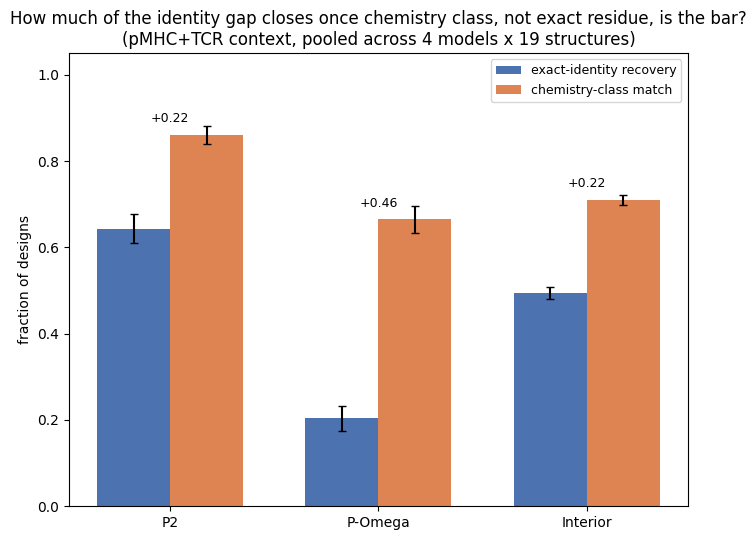

wrote /home/ubuntu/if-mhc/figures/fig_panel7_chemistry/fig_panel7_recovery_vs_class_match.png
P2         recovery=0.644  class_match=0.860  gain=0.217
P-Omega    recovery=0.204  class_match=0.665  gain=0.461
Interior   recovery=0.494  class_match=0.709  gain=0.215


In [5]:
rec_means = [stats_full[f"{prefix_map[g]}_recovery"].mean() for g in groups]
rec_sems = [stats_full[f"{prefix_map[g]}_recovery"].sem() for g in groups]
cm_means = [stats_full[f"{prefix_map[g]}_class_match"].mean() for g in groups]
cm_sems = [stats_full[f"{prefix_map[g]}_class_match"].sem() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5.5))
x = np.arange(len(groups))
width = 0.35
ax.bar(x - width / 2, rec_means, width, yerr=rec_sems, capsize=3, color="#4C72B0",
      label="exact-identity recovery")
ax.bar(x + width / 2, cm_means, width, yerr=cm_sems, capsize=3, color="#DD8452",
      label="chemistry-class match")
for xi, r, c in zip(x, rec_means, cm_means):
    ax.annotate(f"+{c - r:.2f}", xy=(xi, max(r, c) + 0.03), ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 1.05)
ax.set_ylabel("fraction of designs")
ax.set_title("How much of the identity gap closes once chemistry class, not exact residue, is the bar?\n"
             "(pMHC+TCR context, pooled across 4 models x 19 structures)")
ax.legend(fontsize=9)
fig.tight_layout()
out = FIG_DIR / "fig_panel7_recovery_vs_class_match.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
for g, r, c in zip(groups, rec_means, cm_means):
    print(f"{g:10s} recovery={r:.3f}  class_match={c:.3f}  gain={c - r:.3f}")

## 5. Continuous hydrophobicity distributions of designed residues

The discrete 5-class scheme has a known blind spot: cysteine is grouped with the polar/uncharged residues
on the strength of its thiol group, despite a Kyte-Doolittle value ($2.5$) that is more hydrophobic than
several residues classed as "nonpolar aliphatic" (glycine, $-0.4$; proline, $-1.6$). Four of the panel's
nineteen native peptides (the SLLMWITQC / NY-ESO-1 replicates) carry a cysteine at P$\Omega$, so this is
not a hypothetical edge case for this panel specifically. The continuous KD scale sidesteps that
misclassification.

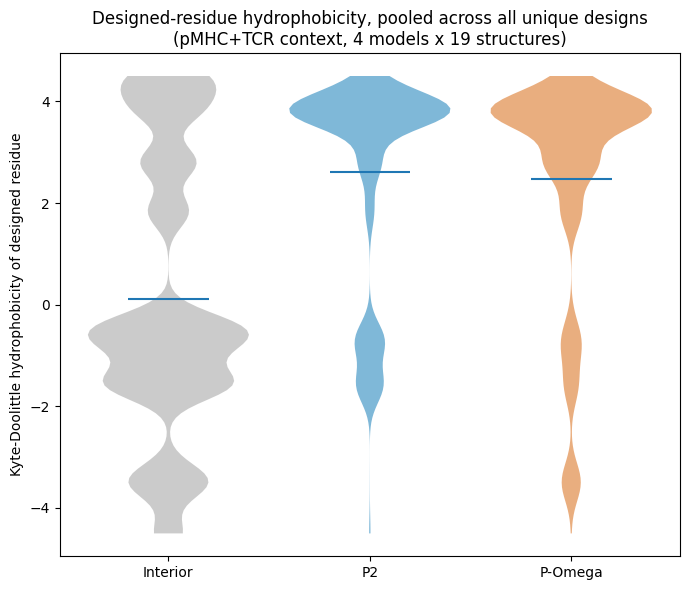

wrote /home/ubuntu/if-mhc/figures/fig_panel7_chemistry/fig_panel7_kd_violin_full.png
n: interior=49066, P2=7828, P-Omega=7828
SD: interior=2.73, P2=2.09, P-Omega=2.24


In [6]:
def residue_kd_list(data, position_prefix):
    vals = []
    for pdb in PDBS:
        native = natives[pdb]
        length = len(native)
        sub = data[data.pdb == pdb]
        if position_prefix == "interior":
            for i in interior_idx_of(length):
                vals.extend(KD[p[i]] for p in sub["peptide"])
        else:
            idx = {"p2": 1, "pomega": length - 1}[position_prefix]
            vals.extend(KD[p[idx]] for p in sub["peptide"])
    return vals

kd_p2 = residue_kd_list(meta, "p2")
kd_pomega = residue_kd_list(meta, "pomega")
kd_interior = residue_kd_list(meta, "interior")

fig, ax = plt.subplots(figsize=(7, 6))
parts = ax.violinplot([kd_interior, kd_p2, kd_pomega], positions=[0, 1, 2], showmeans=True,
                      showextrema=False, widths=0.8)
for pc, color in zip(parts["bodies"], ["#999999", POS_COLOR["P2"], POS_COLOR["P-Omega"]]):
    pc.set_facecolor(color); pc.set_alpha(0.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Interior", "P2", "P-Omega"])
ax.set_ylabel("Kyte-Doolittle hydrophobicity of designed residue")
ax.set_title("Designed-residue hydrophobicity, pooled across all unique designs\n"
             "(pMHC+TCR context, 4 models x 19 structures)")
fig.tight_layout()
out = FIG_DIR / "fig_panel7_kd_violin_full.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(f"n: interior={len(kd_interior)}, P2={len(kd_p2)}, P-Omega={len(kd_pomega)}")
print(f"SD: interior={np.std(kd_interior):.2f}, P2={np.std(kd_p2):.2f}, P-Omega={np.std(kd_pomega):.2f}")

## 6. Does removing the TCR erode chemistry-level constraint, or just identity-level recovery?

`06_mhcflurry_esmcba_umap.ipynb` (Section 7) established that removing the TCR increases sampled
diversity and, for two of the four models, predicted affinity, while `03_recovery_presentation.ipynb`
and `05_skempi_validation.ipynb` show it lowers exact-identity recovery, most clearly at experimentally
validated TCR-contact positions. Here: does the extra sequence diversity gained at P$\Omega$ without the
TCR still respect the pocket's chemistry (more different hydrophobic residues), or does it spend some of
that diversity on genuinely different chemistry classes?

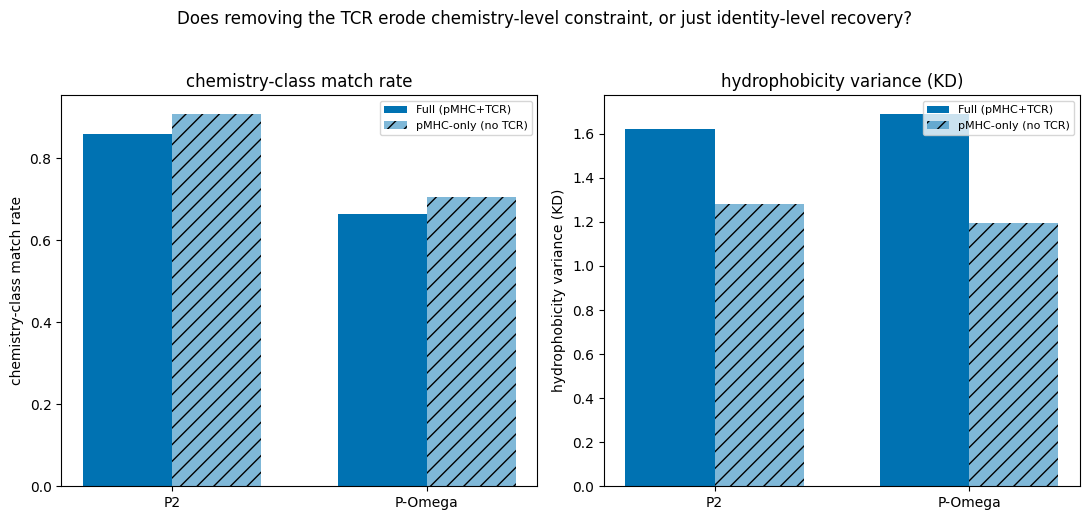

wrote /home/ubuntu/if-mhc/figures/fig_panel7_chemistry/fig_panel7_full_vs_notcr_chemistry.png
p2       chemistry-class match rate   full=0.860  no-TCR=0.909
pomega   chemistry-class match rate   full=0.665  no-TCR=0.706
p2       hydrophobicity variance (KD) full=1.622  no-TCR=1.279
pomega   hydrophobicity variance (KD) full=1.690  no-TCR=1.196


In [7]:
metrics = [("class_match", "chemistry-class match rate"), ("kd_var", "hydrophobicity variance (KD)")]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (metric, mlabel) in zip(axes, metrics):
    x = np.arange(2)
    width = 0.35
    full_vals = [stats_full[f"p2_{metric}"].mean(), stats_full[f"pomega_{metric}"].mean()]
    mhconly_vals = [stats_mhconly[f"p2_{metric}"].mean(), stats_mhconly[f"pomega_{metric}"].mean()]
    ax.bar(x - width / 2, full_vals, width, color="#0072B2", label="Full (pMHC+TCR)")
    ax.bar(x + width / 2, mhconly_vals, width, color="#0072B2", alpha=0.5, hatch="//",
          label="pMHC-only (no TCR)")
    ax.set_xticks(x)
    ax.set_xticklabels(["P2", "P-Omega"])
    ax.set_ylabel(mlabel)
    ax.set_title(mlabel)
    ax.legend(fontsize=8)
fig.suptitle("Does removing the TCR erode chemistry-level constraint, or just identity-level recovery?",
            y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel7_full_vs_notcr_chemistry.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
for metric, mlabel in metrics:
    for anchor in ["p2", "pomega"]:
        full_v = stats_full[f"{anchor}_{metric}"].mean()
        mhconly_v = stats_mhconly[f"{anchor}_{metric}"].mean()
        print(f"{anchor:8s} {mlabel:28s} full={full_v:.3f}  no-TCR={mhconly_v:.3f}")